# 1. Entendimiento del Negocio
## Contexto General:
La calidad y el acceso a la educación en Colombia presentan disparidades significativas entre las zonas urbanas y rurales. Factores macroeconómicos como el índice de pobreza multidimensional, la infraestructura tecnológica (conectividad a internet) y los recursos asignados a las instituciones educativas juegan un rol crítico en el desempeño académico de los estudiantes.
## Objetivo del Negocio (Consultoría):
El objetivo principal del equipo de consultoría es diseñar un plan de acción estratégico para el Ministerio de Educación, respaldado por el análisis de datos masivos. Se busca identificar las causas subyacentes de los bajos resultados en las pruebas ICFES Saber 11 y su relación con factores territoriales, como la disponibilidad de internet y las tasas de deserción y cobertura, para proponer políticas públicas de mejora focalizadas por municipio.

# 2. Selección de los Datos a Utilizar
Para el desarrollo de la primera fase del proyecto, se utilizará el conjunto de datos de educación básica y media (Estadisticas-de-Educacion-en-Preescolar-Basica-y-Media-por-Municipio.csv).
Razón de selección: Este dataset permite entender la estructura base del sistema educativo territorial. Contiene variables clave como cobertura neta, deserción, aprobación y repitencia en todos los niveles escolares (transición, primaria, secundaria y media). Estas variables son fundamentales para cruzarlas posteriormente con los resultados del ICFES y el acceso a internet, permitiéndonos identificar en dónde el sistema está fallando antes de que el estudiante llegue a presentar la prueba estatal.

# 3. Colección y Descripción de Datos
En este apartado inicializamos el clúster local de Apache Spark, cargamos los datos y verificamos los esquemas y significados.

In [0]:
# Importar librerías necesarias de PySpark
from pyspark.sql import SparkSession
from pyspark.sql.functions import col, isnan, when, count, regexp_replace, mean
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Iniciar sesión de Spark (Simulando el clúster)
spark = SparkSession.builder.appName("MinEducacion_Proyecto").getOrCreate()

# Cargar el dataset - usar pandas primero y luego convertir a Spark
file_path_sup = "/Workspace/Users/gabrielcamachor@javeriana.edu.co/Proyecto de PDD/ProyectoSparkies/Estadisticas-Matricula-por-Municipio.csv"
df_sup_pandas = pd.read_csv(file_path_sup)
df_sup_raw = spark.createDataFrame(df_sup_pandas)

# Mostrar el esquema original
print("--- ESQUEMA DE DATOS ORIGINAL (EDUCACIÓN SUPERIOR) ---")
df_sup_raw.printSchema()

# Descripción general del contenido
print(f"Total de registros (filas): {df_sup_raw.count()}")
print(f"Total de atributos (columnas): {len(df_sup_raw.columns)}")

--- ESQUEMA DE DATOS ORIGINAL (EDUCACIÓN SUPERIOR) ---
root
 |-- AÑO: long (nullable = true)
 |-- Código delDepartamento: long (nullable = true)
 |-- Nombre del Departamento: long (nullable = true)
 |-- Código delMunicipio: long (nullable = true)
 |-- Nombre del Municipio: string (nullable = true)
 |-- TECNICA PROFESIONAL: double (nullable = true)
 |-- TECNOLOGICA: double (nullable = true)
 |-- UNIVERSITARIA: double (nullable = true)
 |-- ESPECIALIZACION: double (nullable = true)
 |-- MAESTRIA: double (nullable = true)
 |-- DOCTORADO: long (nullable = true)
 |-- IES CON OFERTA: long (nullable = true)

Total de registros (filas): 1368
Total de atributos (columnas): 12


## Comprensión del significado de atributos clave:

MUNICIPIO / DEPARTAMENTO: Identificadores geográficos de las entidades.

TASA_MATRICULACIÓN_5_16: Porcentaje de la población en edad escolar efectivamente matriculada.

COBERTURA_NETA / BRUTA: Indicadores de capacidad del sistema educativo por nivel (transición, primaria, etc.).

DESERCIÓN, APROBACIÓN, REPITENCIA: Tasas de rendimiento y permanencia estudiantil.

SEDES_CONECTADAS_A_INTERNET: Refleja la brecha de infraestructura digital.

# 4. Exploración de los Datos
Se presentan 8 elementos exploratorios (descriptivos, agrupaciones y gráficas) para comprender la distribución de la información escolar territorial.

✅ Archivo correcto cargado. Procesando gráficas...

--- TOP 5 MUNICIPIOS CON MAYOR MATRÍCULA UNIVERSITARIA (2021) ---
+--------------------+-----------------+----------------------+
|           MUNICIPIO|TOTAL_ESTUDIANTES|CANTIDAD_UNIVERSIDADES|
+--------------------+-----------------+----------------------+
|               Tunja|            37261|                    12|
|            Sogamoso|            15987|                     6|
|             Duitama|            10880|                     7|
|Santa Rosa De Vit...|             9880|                     1|
|        Chiquinquirá|             5367|                     6|
+--------------------+-----------------+----------------------+
only showing top 5 rows


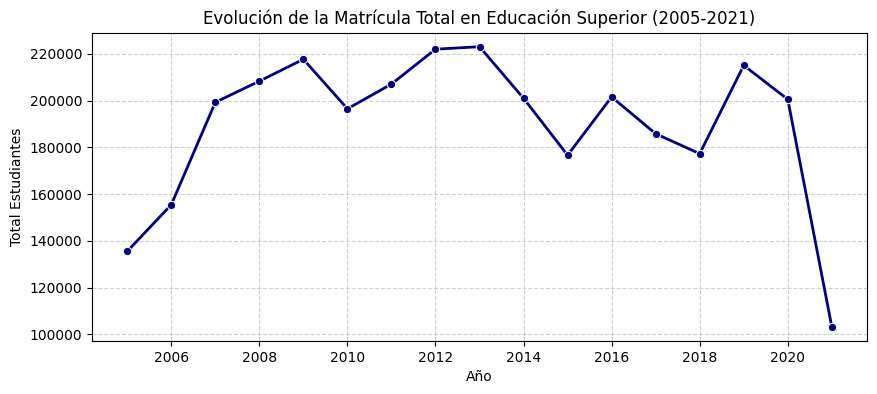


--- MATRIZ DE CORRELACIÓN DE OFERTA Y DEMANDA (2021) ---


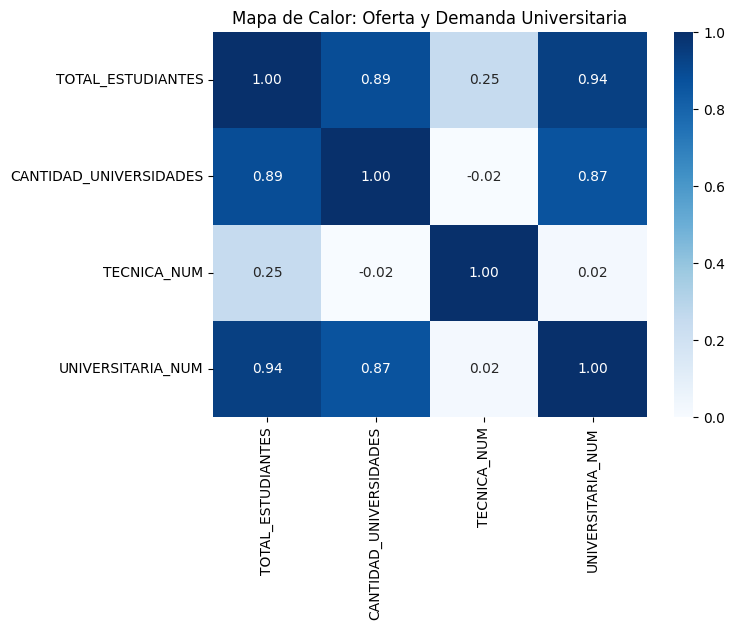

In [0]:
# 1. Importar librerías necesarias
from pyspark.sql import SparkSession
from pyspark.sql.functions import col, regexp_replace
from functools import reduce
from operator import add
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# 2. Iniciar sesión y definir la ruta exacta de EDUCACIÓN SUPERIOR
spark = SparkSession.builder.getOrCreate()
ruta_superior = "/Workspace/Users/gabrielcamachor@javeriana.edu.co/Proyecto de PDD/ProyectoSparkies/Estadisticas-Matricula-por-Municipio.csv"

# 3. Cargar el dataset - usar pandas primero y luego convertir a Spark
df_matricula_pandas = pd.read_csv(ruta_superior)
df_matricula_raw = spark.createDataFrame(df_matricula_pandas)

# 4. VALIDADOR ANTIFALLOS: Comprobar que Databricks no haya cargado el archivo viejo
if "DESERCIÓN" in df_matricula_raw.columns:
    print("❌ ERROR DE DATABRICKS: Está leyendo el archivo de colegios. Verifica que el archivo 'Estadisticas-Matricula-por-Municipio.csv' esté subido en la carpeta 'ProyectoSparkies'.")
else:
    print("✅ Archivo correcto cargado. Procesando gráficas...\n")

    # 5. Transformaciones: Renombrar columnas conflictivas
    df_matricula = df_matricula_raw.withColumnRenamed("TECNICA PROFESIONAL", "TECNICA") \
                                   .withColumnRenamed("Nombre del Municipio", "MUNICIPIO") \
                                   .withColumnRenamed("IES CON OFERTA", "CANTIDAD_UNIVERSIDADES")

    # 6. Limpieza de separadores de miles (quitar puntos y pasar a número)
    niveles_superiores = ['TECNICA', 'TECNOLOGICA', 'UNIVERSITARIA', 'ESPECIALIZACION', 'MAESTRIA', 'DOCTORADO']
    for c in niveles_superiores:
        df_matricula = df_matricula.withColumn(f"{c}_NUM", regexp_replace(col(c).cast("string"), "\\.", "").cast("int"))

    # 7. Sumatoria del total de estudiantes
    columnas_a_sumar = [col(f"{c}_NUM") for c in niveles_superiores]
    df_matricula = df_matricula.withColumn("TOTAL_ESTUDIANTES", reduce(add, columnas_a_sumar))

    # 8. Filtro para el año 2021
    df_2021 = df_matricula.filter(col("AÑO") == 2021)
    
    print("--- TOP 5 MUNICIPIOS CON MAYOR MATRÍCULA UNIVERSITARIA (2021) ---")
    df_2021.orderBy(col("TOTAL_ESTUDIANTES").desc()).select("MUNICIPIO", "TOTAL_ESTUDIANTES", "CANTIDAD_UNIVERSIDADES").show(5)

    # 9. Pasar a Pandas para graficar
    pdf_completo = df_matricula.select("AÑO", "MUNICIPIO", "CANTIDAD_UNIVERSIDADES", "TOTAL_ESTUDIANTES", 
                                       "TECNICA_NUM", "UNIVERSITARIA_NUM").toPandas()
    pdf_2021 = pdf_completo[pdf_completo['AÑO'] == 2021]

    # --- GRÁFICO 1: TENDENCIA HISTÓRICA ---
    plt.figure(figsize=(10,4))
    tendencia = pdf_completo.groupby('AÑO')['TOTAL_ESTUDIANTES'].sum()
    sns.lineplot(x=tendencia.index, y=tendencia.values, marker='o', color='navy', linewidth=2)
    plt.title('Evolución de la Matrícula Total en Educación Superior (2005-2021)')
    plt.ylabel('Total Estudiantes')
    plt.xlabel('Año')
    plt.grid(True, linestyle='--', alpha=0.6)
    plt.show()

    # --- GRÁFICO 2: MATRIZ DE CORRELACIÓN ---
    print("\n--- MATRIZ DE CORRELACIÓN DE OFERTA Y DEMANDA (2021) ---")
    correlaciones = pdf_2021[['TOTAL_ESTUDIANTES', 'CANTIDAD_UNIVERSIDADES', 'TECNICA_NUM', 'UNIVERSITARIA_NUM']].corr()
    
    plt.figure(figsize=(7,5))
    sns.heatmap(correlaciones, annot=True, cmap='Blues', vmin=0, vmax=1, fmt=".2f")
    plt.title('Mapa de Calor: Oferta y Demanda Universitaria')
    plt.show()

# 5. Reporte de Calidad de Datos
Identificamos la cantidad de valores nulos o faltantes en el sistema y proponemos estrategias para mitigar el impacto en el modelo.

In [0]:
from pyspark.sql.functions import count, when, isnan

print("--- REPORTE DE VALORES FALTANTES (EDUCACIÓN SUPERIOR) ---")

expresiones_nulos_sup = []
for columna, tipo in df_matricula_raw.dtypes:
    if tipo == 'string':
        condicion = col(columna).isNull() | (col(columna) == "") | (col(columna) == "NaN")
    else:
        condicion = col(columna).isNull() | isnan(columna)
        
    expresiones_nulos_sup.append(count(when(condicion, columna)).alias(columna))

# Mostramos el reporte
df_matricula_raw.select(expresiones_nulos_sup).show(vertical=True)

--- REPORTE DE VALORES FALTANTES (EDUCACIÓN SUPERIOR) ---
-RECORD 0----------------------
 AÑO                     | 0   
 Código delDepartamento  | 0   
 Nombre del Departamento | 0   
 Código delMunicipio     | 0   
 Nombre del Municipio    | 0   
 TECNICA PROFESIONAL     | 0   
 TECNOLOGICA             | 0   
 UNIVERSITARIA           | 0   
 ESPECIALIZACION         | 0   
 MAESTRIA                | 0   
 DOCTORADO               | 0   
 IES CON OFERTA          | 0   



## Técnicas propuestas para tratar valores faltantes:

###Imputación por la media/mediana: 
Para variables métricas continuas con pocos valores nulos (ej. COBERTURA_NETA_PRIMARIA, que tiene 2 faltantes).

###Imputación por agrupamiento (Clustering): 
Para métricas territoriales como TAMAÑO_PROMEDIO_DE_GRUPO, se puede imputar utilizando el promedio estadístico del departamento al que pertenece dicho municipio.

###Eliminación (Drop): 
Si un municipio carece por completo de la mayoría de los indicadores educativos, se eliminará el registro (fila) para evitar sesgar el análisis.

#6. Planteamiento de Preguntas sobre los Datos
De cara a la segunda fase del proyecto, plantearemos las siguientes 8 preguntas de negocio estratégicas:

¿Cuál es la relación matemática entre el número de sedes conectadas a internet de un municipio y sus tasas promedio de aprobación en educación media?

¿Cómo varía la deserción en la educación media en municipios con baja cobertura bruta frente a los de alta cobertura?

¿Cuál es el departamento con mayor tasa de repitencia en educación primaria y qué factores territoriales se asocian a este comportamiento?

¿En qué medida el tamaño promedio de grupo (hacinamiento escolar) afecta la tasa de reprobación secundaria a nivel regional?

¿Cuáles son los 10 municipios que presentan la mayor brecha de cobertura neta entre la educación primaria y la educación media?

¿Existe una correlación directa entre el nivel de pobreza de un municipio (futuro dataset a cruzar) y sus tasas de deserción escolar global?

¿Cómo ha impactado la tasa de matriculación general de la población (5 a 16 años) en la cobertura bruta específicamente en el nivel de transición?

¿Qué características demográficas y de infraestructura comparten los municipios que logran mantener tasas de reprobación menores al 3% en educación secundaria?

#7. Filtros, Limpieza y Transformación Inicial
Para poder cruzar eficientemente este conjunto de datos con los resultados del ICFES, debemos asegurarnos de que los valores de tasas (que vienen con % y comas decimales) se conviertan estrictamente a tipos numéricos, y purgar los datos atípicos.

In [0]:
# Transformación 1: Renombrar columnas para evitar errores sintácticos de SQL/Spark
df_matricula_clean = df_matricula_raw.withColumnRenamed("Nombre del Municipio", "MUNICIPIO") \
                                     .withColumnRenamed("Código delMunicipio", "CODIGO_MUNICIPIO") \
                                     .withColumnRenamed("Nombre del Departamento", "DEPARTAMENTO") \
                                     .withColumnRenamed("TECNICA PROFESIONAL", "TECNICA") \
                                     .withColumnRenamed("IES CON OFERTA", "CANTIDAD_UNIVERSIDADES")

# Transformación 2: Estandarización estricta de las matrículas (Eliminar puntos de miles)
niveles_superiores = ['TECNICA', 'TECNOLOGICA', 'UNIVERSITARIA', 'ESPECIALIZACION', 'MAESTRIA', 'DOCTORADO']

for c in niveles_superiores:
    df_matricula_clean = df_matricula_clean.withColumn(c, regexp_replace(col(c).cast("string"), "\\.", "").cast("int"))

# Transformación 3: Totalizadores
columnas_estudiantes = [col(c) for c in niveles_superiores]
df_matricula_clean = df_matricula_clean.withColumn("TOTAL_ESTUDIANTES", reduce(add, columnas_estudiantes))

# Filtro 1: Nos aseguramos de mantener únicamente la data del Departamento de Boyacá (Código 15)
df_matricula_clean = df_matricula_clean.filter(col("Código delDepartamento") == 15)

# Filtro 2: Descartamos las columnas de códigos territoriales que no usaremos en los modelos
df_matricula_clean = df_matricula_clean.drop("Código delDepartamento", "DEPARTAMENTO")

print("--- MUESTRA DEL DATASET SUPERIOR DEFINITIVO (LIMPIO) ---")
df_matricula_clean.select("AÑO", "MUNICIPIO", "TECNICA", "UNIVERSITARIA", "CANTIDAD_UNIVERSIDADES", "TOTAL_ESTUDIANTES").show(5)

--- MUESTRA DEL DATASET SUPERIOR DEFINITIVO (LIMPIO) ---
+----+------------+-------+-------------+----------------------+-----------------+
| AÑO|   MUNICIPIO|TECNICA|UNIVERSITARIA|CANTIDAD_UNIVERSIDADES|TOTAL_ESTUDIANTES|
+----+------------+-------+-------------+----------------------+-----------------+
|2005|       TUNJA|   3400|        20021|                    11|            32956|
|2005|CHIQUINQUIRÁ|    760|         6940|                     4|             7940|
|2005|     CHIVATÁ|    340|            0|                     1|              340|
|2005|     DUITAMA|    340|         2817|                     5|             3967|
|2005|  FIRAVITOBA|    370|            0|                     1|              370|
+----+------------+-------+-------------+----------------------+-----------------+
only showing top 5 rows
